# CMS hospital benchmarking

Charts from the cleaned CMS hospital mart. No UCI. No new joins to raw files.

SQL in notebook `04` already ranked hospitals and counted missing stars. This notebook is the picture version of those same rules: **peer groups first**, national lists second, **missing is not zero**.

**What this step is for**

A quality leader can see whether a hospital's heart-failure readmission score looks unusual *among hospitals of the same type, ownership, and region*, and whether patient-experience scores move with that readmission score. They cannot treat a national star leaderboard as the answer.

**Questions**

1. Which large peer groups have the widest published HF readmission spreads, and who sits at the bottom of those groups?
2. Do HCAHPS overall-rating scores move with HF readmission scores (association only)?
3. What do state and region averages hide if unpublished hospitals are ignored?

**Words used here**

- **Peer group.** Hospital type × ownership × Census region. Compare inside that box before any national rank.
- **Published score.** CMS printed a number. `Not Available` / too few cases stay blank.
- **CMS label.** Better / no different / worse than the national rate. That is CMS's comparison, not ours.
- **Association.** Two published numbers that move together. Not a cause.
- **Unadjusted state view.** A state mean among hospitals that published a star. It is not a peer comparison.

**Steps**

1. Load `cms_facility_mart.csv`. IDs stay text.
2. Count who has a star, an HF score, and an HCAHPS overall rating.
3. Rank published HF scores inside each peer. Flag CMS-worse hospitals in peers of 20 or more.
4. Chart peer spreads, experience vs HF, and a state view that shows how many hospitals were rated.
5. Save figures to `figures/`.

This is not a UCI `<30` rate.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats


In [2]:
def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "processed").is_dir():
            return path
    raise FileNotFoundError(
        "Could not find the project root. Run this notebook from the "
        "repository folder or from notebooks/."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

print(PROJECT_ROOT)
print(FIGURES_DIR)


c:\Users\Micaela\Documents\CODING\hospital-operations-analytics
c:\Users\Micaela\Documents\CODING\hospital-operations-analytics\figures


## Load the hospital mart

One row per facility. I only use columns the KPI dictionary already locked: overall star, `READM_30_HF`, HCAHPS overall linear score, and the peer fields. I do not fill blanks.


In [3]:
mart = pd.read_csv(
    PROCESSED_DATA_DIR / "cms_facility_mart.csv",
    dtype={"facility_id": "string", "zip_code": "string", "phone": "string"},
)
assert mart["facility_id"].nunique() == len(mart) == 5419
assert mart["facility_id"].str.len().eq(6).all()

mart["peer"] = (
    mart["hospital_type"].fillna("(missing type)")
    + " | "
    + mart["hospital_ownership"].fillna("(missing ownership)")
    + " | "
    + mart["census_region"].fillna("(missing region)")
)


def short_peer(row: pd.Series) -> str:
    type_map = {
        "Acute Care Hospitals": "Acute",
        "Critical Access Hospitals": "CAH",
        "Childrens": "Children's",
        "Children's": "Children's",
    }
    own = row["hospital_ownership"] or ""
    if "Voluntary non-profit - Private" in own:
        own_s = "Vol-NP-Priv"
    elif own.startswith("Proprietary"):
        own_s = "Proprietary"
    elif "Hospital District" in own:
        own_s = "Gov-District"
    elif "Voluntary non-profit - Church" in own:
        own_s = "Vol-NP-Church"
    elif "Voluntary non-profit - Other" in own:
        own_s = "Vol-NP-Other"
    elif own.startswith("Government - Local"):
        own_s = "Gov-Local"
    elif own.startswith("Veterans"):
        own_s = "VA"
    else:
        own_s = (own[:16] + "…") if len(own) > 16 else own
    return f"{type_map.get(row['hospital_type'], row['hospital_type'])} | {own_s} | {row['census_region']}"


mart["peer_short"] = mart.apply(short_peer, axis=1)

n = len(mart)
n_star = mart["overall_rating"].notna().sum()
n_hf = mart["readm_30_hf_score"].notna().sum()
n_hsp = mart["h_hsp_rating_linear_score"].notna().sum()
n_both = (
    mart["readm_30_hf_score"].notna() & mart["h_hsp_rating_linear_score"].notna()
).sum()
print(f"hospitals: {n:,}")
print(f"overall star: {n_star:,} published, {n - n_star:,} missing")
print(f"HF readmission score: {n_hf:,} published, {n - n_hf:,} missing")
print(f"HCAHPS overall linear: {n_hsp:,} published")
print(f"both HF score and HCAHPS linear: {n_both:,}")
print(mart["readm_30_hf_compared"].value_counts(dropna=False))


hospitals: 5,419
overall star: 3,174 published, 2,245 missing
HF readmission score: 3,253 published, 2,166 missing
HCAHPS overall linear: 3,183 published
both HF score and HCAHPS linear: 2,960
readm_30_hf_compared
No different than the national rate    3194
NaN                                    1146
Number of cases too small              1020
Worse than the national rate             38
Better than the national rate            21
Name: count, dtype: int64


## Who published a number?

Before any average, count the blanks. A region or ownership type that publishes fewer scores is not automatically worse.


,census_region,n_hospitals,n_star,n_hf,n_hsp,pct_star,pct_hf
2,South,2072,1186,1222,1180,0.572394,0.589768
0,Midwest,1537,857,868,842,0.557580,0.564736
4,West,1076,643,635,671,0.597584,0.590149
1,Northeast,669,478,484,480,0.714499,0.723468
3,Territory,65,10,44,10,0.153846,0.676923


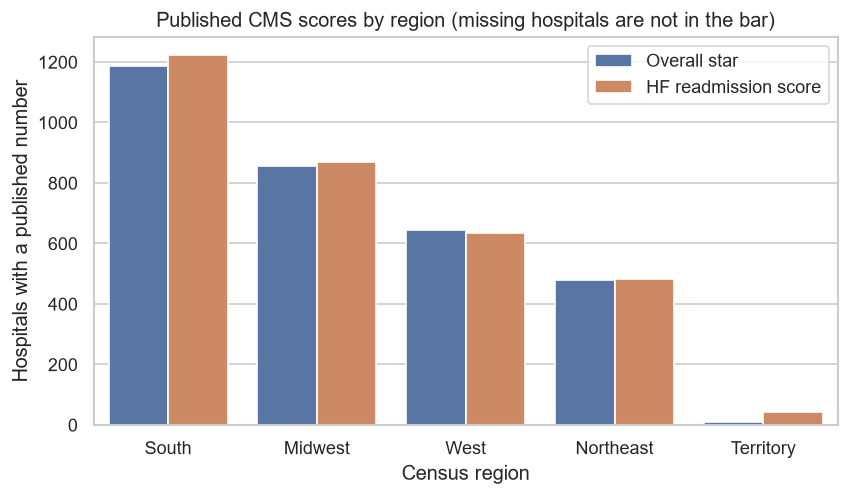

In [4]:
pub = (
    mart.groupby("census_region", dropna=False)
    .agg(
        n_hospitals=("facility_id", "size"),
        n_star=("overall_rating", "count"),
        n_hf=("readm_30_hf_score", "count"),
        n_hsp=("h_hsp_rating_linear_score", "count"),
    )
    .reset_index()
)
pub["pct_star"] = pub["n_star"] / pub["n_hospitals"]
pub["pct_hf"] = pub["n_hf"] / pub["n_hospitals"]
display(pub.sort_values("n_hospitals", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4.2))
order = pub.sort_values("n_hospitals", ascending=False)["census_region"]
plot_df = pub.melt(
    id_vars="census_region",
    value_vars=["n_star", "n_hf"],
    var_name="measure",
    value_name="n_published",
)
plot_df["measure"] = plot_df["measure"].map(
    {"n_star": "Overall star", "n_hf": "HF readmission score"}
)
sns.barplot(
    data=plot_df,
    x="census_region",
    y="n_published",
    hue="measure",
    order=order,
    ax=ax,
)
ax.set_xlabel("Census region")
ax.set_ylabel("Hospitals with a published number")
ax.set_title("Published CMS scores by region (missing hospitals are not in the bar)")
ax.legend(title="")
fig.savefig(FIGURES_DIR / "cms_publication_by_region.png")
plt.show()


## Peer groups on heart-failure readmission

I rank only hospitals with a published `READM_30_HF` score. Lower is better. Peers smaller than 20 stays in the table as context; I will not call an outlier from them.


In [5]:
hf = mart.loc[mart["readm_30_hf_score"].notna()].copy()
hf["rank_in_peer"] = hf.groupby("peer")["readm_30_hf_score"].rank(
    method="min", ascending=True
)
hf["n_in_peer"] = hf.groupby("peer")["readm_30_hf_score"].transform("size")

peer_summary = (
    hf.groupby(["peer", "peer_short", "hospital_type", "hospital_ownership", "census_region"], dropna=False)
    .agg(
        n_in_peer=("facility_id", "size"),
        min_score=("readm_30_hf_score", "min"),
        median_score=("readm_30_hf_score", "median"),
        max_score=("readm_30_hf_score", "max"),
        n_worse=("readm_30_hf_compared", lambda s: (s == "Worse than the national rate").sum()),
        n_better=("readm_30_hf_compared", lambda s: (s == "Better than the national rate").sum()),
    )
    .reset_index()
)
peer_summary["spread"] = peer_summary["max_score"] - peer_summary["min_score"]
large = peer_summary.loc[peer_summary["n_in_peer"] >= 20].sort_values(
    "n_in_peer", ascending=False
)
print(
    f"{len(peer_summary)} peer groups. {len(large)} have 20+ published HF scores "
    f"({int(large['n_in_peer'].sum()):,} of {len(hf):,} scored hospitals)."
)
print("Largest spreads among peers with 20+ scores:")
display(
    large.sort_values("spread", ascending=False)[
        ["peer_short", "n_in_peer", "min_score", "median_score", "max_score", "spread", "n_worse"]
    ].head(8)
)


68 peer groups. 28 have 20+ published HF scores (2,968 of 3,253 scored hospitals).
Largest spreads among peers with 20+ scores:


,peer_short,n_in_peer,min_score,median_score,max_score,spread,n_worse
39,Acute | Vol-NP-Priv | Midwest,357,17.7,21.2,28.4,10.7,4
40,Acute | Vol-NP-Priv | Northeast,317,18.0,21.7,27.6,9.6,6
43,Acute | Vol-NP-Priv | West,247,17.3,20.8,26.7,9.4,3
41,Acute | Vol-NP-Priv | South,474,17.3,21.2,25.1,7.8,2
28,Acute | Proprietary | West,114,17.6,21.4,25.3,7.7,3
2,Acute Care - Veterans Administration | VA | South,46,19.2,21.7,26.4,7.2,1
36,Acute | Vol-NP-Other | Northeast,35,18.6,21.5,25.7,7.1,1
26,Acute | Proprietary | South,291,17.8,21.7,24.5,6.7,0


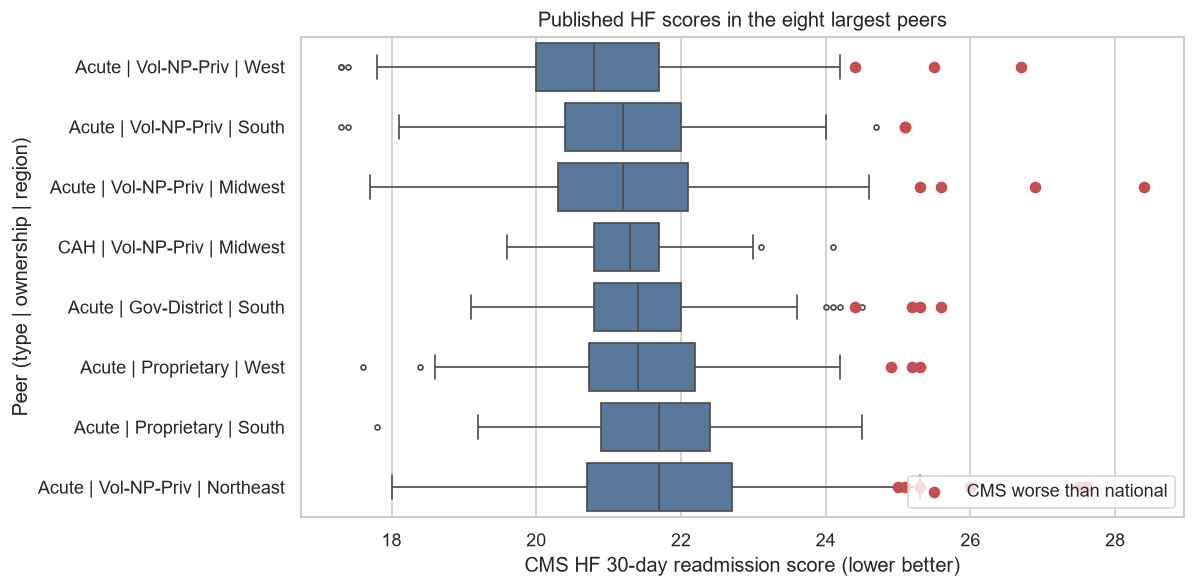

In [6]:
top_peers = large.head(8)["peer"].tolist()
box = hf.loc[hf["peer"].isin(top_peers)].copy()
order_short = (
    large.head(8)
    .sort_values("median_score")["peer_short"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
sns.boxplot(
    data=box,
    x="readm_30_hf_score",
    y="peer_short",
    order=order_short,
    color="#4C78A8",
    fliersize=3,
    ax=ax,
)
sns.stripplot(
    data=box.loc[box["readm_30_hf_compared"] == "Worse than the national rate"],
    x="readm_30_hf_score",
    y="peer_short",
    order=order_short,
    color="#C44E52",
    size=7,
    jitter=False,
    ax=ax,
    label="CMS worse than national",
)
ax.set_xlabel("CMS HF 30-day readmission score (lower better)")
ax.set_ylabel("Peer (type | ownership | region)")
ax.set_title("Published HF scores in the eight largest peers")
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles[:1], labels[:1], loc="lower right")
fig.savefig(FIGURES_DIR / "cms_hf_score_by_large_peer.png")
plt.show()


### Who looks unusual among similar hospitals?

CMS already printed "Worse than the national rate." The extra cut is: that label, and last or near-last in a peer of 20 or more. A 1-of-1 rank is not on this list.


In [7]:
review = hf.loc[
    (hf["readm_30_hf_compared"] == "Worse than the national rate")
    & (hf["n_in_peer"] >= 20)
].copy()
review["from_bottom"] = review["n_in_peer"] - review["rank_in_peer"] + 1
review = review.sort_values(
    ["readm_30_hf_score", "n_in_peer"], ascending=[False, False]
)
print(f"CMS-worse and peer n >= 20: {len(review)} hospitals")
display(
    review[
        [
            "facility_id",
            "facility_name",
            "state",
            "peer_short",
            "readm_30_hf_score",
            "readm_30_hf_denominator",
            "rank_in_peer",
            "n_in_peer",
        ]
    ].head(15)
)


CMS-worse and peer n >= 20: 29 hospitals


,facility_id,facility_name,state,peer_short,readm_30_hf_score,readm_30_hf_denominator,rank_in_peer,n_in_peer
2337,230017,BRONSON METHODIST HOSPITAL,MI,Acute | Vol-NP-Priv | Midwest,28.4,1088.0,357.0,357
3332,330399,ST BARNABAS HOSPITAL,NY,Acute | Vol-NP-Priv | Northeast,27.6,273.0,317.0,317
3201,330009,BRONXCARE HOSPITAL CENTER,NY,Acute | Vol-NP-Priv | Northeast,27.5,762.0,316.0,317
3625,360125,ASHTABULA COUNTY MEDICAL CENTER,OH,Acute | Vol-NP-Priv | Midwest,26.9,332.0,356.0,357
335,050030,OROVILLE HOSPITAL,CA,Acute | Vol-NP-Priv | West,26.7,239.0,247.0,247
263,04010F,VA CENTRAL AR. VETERANS HEALTHCARE SYSTEM LR,AR,Acute Care - Veterans Administration | VA | South,26.4,627.0,46.0,46
3296,330226,UNITY HOSPITAL,NY,Acute | Vol-NP-Priv | Northeast,26.0,1071.0,315.0,317
3219,330056,BROOKLYN HOSPITAL CENTER - DOWNTOWN CAMPUS,NY,Acute | Vol-NP-Other | Northeast,25.7,253.0,35.0,35
3669,360354,WEST CHESTER HOSPITAL,OH,Acute | Vol-NP-Priv | Midwest,25.6,532.0,355.0,357
1129,110105,COLQUITT REGIONAL MEDICAL CENTER,GA,Acute | Gov-District | South,25.6,427.0,145.0,145


## Patient experience and HF readmission

HCAHPS overall linear score (higher better) vs published HF score (lower better). Only hospitals that have both numbers. Correlation is association. It is not "better experience prevents readmission."


hospitals with both HF and HCAHPS linear: 2,960
Pearson r (HF score, HCAHPS linear): -0.168
Spearman rho: -0.152 (p=1.11e-16)
Pearson r (HF score, overall star): -0.279 (n=3,045)


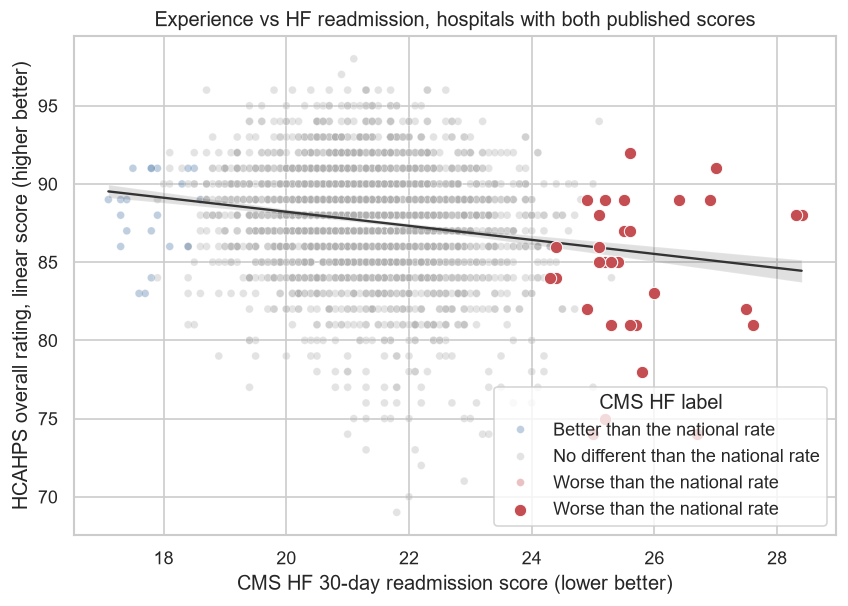

In [8]:
both = mart.loc[
    mart["readm_30_hf_score"].notna() & mart["h_hsp_rating_linear_score"].notna()
].copy()
pearson = both["readm_30_hf_score"].corr(both["h_hsp_rating_linear_score"])
spearman_rho, spearman_p = stats.spearmanr(
    both["readm_30_hf_score"], both["h_hsp_rating_linear_score"]
)
r_star = mart.loc[
    mart["readm_30_hf_score"].notna() & mart["overall_rating"].notna(),
    ["readm_30_hf_score", "overall_rating"],
]
print(f"hospitals with both HF and HCAHPS linear: {len(both):,}")
print(f"Pearson r (HF score, HCAHPS linear): {pearson:.3f}")
print(f"Spearman rho: {spearman_rho:.3f} (p={spearman_p:.2e})")
print(
    "Pearson r (HF score, overall star): "
    f"{r_star['readm_30_hf_score'].corr(r_star['overall_rating']):.3f} "
    f"(n={len(r_star):,})"
)

label_order = [
    "Better than the national rate",
    "No different than the national rate",
    "Worse than the national rate",
]
palette = {
    "Better than the national rate": "#4C78A8",
    "No different than the national rate": "#B0B0B0",
    "Worse than the national rate": "#C44E52",
}
both["hf_label"] = pd.Categorical(
    both["readm_30_hf_compared"].fillna("No different than the national rate"),
    categories=label_order,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(8.2, 5.4))
sns.scatterplot(
    data=both.loc[both["hf_label"] != "Worse than the national rate"],
    x="readm_30_hf_score",
    y="h_hsp_rating_linear_score",
    hue="hf_label",
    palette=palette,
    alpha=0.35,
    s=22,
    ax=ax,
    legend=True,
)
sns.scatterplot(
    data=both.loc[both["hf_label"] == "Worse than the national rate"],
    x="readm_30_hf_score",
    y="h_hsp_rating_linear_score",
    color=palette["Worse than the national rate"],
    s=55,
    ax=ax,
    label="Worse than the national rate",
    zorder=3,
)
sns.regplot(
    data=both,
    x="readm_30_hf_score",
    y="h_hsp_rating_linear_score",
    scatter=False,
    color="#333333",
    line_kws={"linewidth": 1.4},
    ax=ax,
)
ax.set_xlabel("CMS HF 30-day readmission score (lower better)")
ax.set_ylabel("HCAHPS overall rating, linear score (higher better)")
ax.set_title("Experience vs HF readmission, hospitals with both published scores")
ax.legend(title="CMS HF label", loc="best")
fig.savefig(FIGURES_DIR / "cms_hf_vs_hcahps.png")
plt.show()


## State view (unadjusted)

Mean overall star **among hospitals that have a star**, and only for states with at least 20 published stars. Puerto Rico alone is not on this chart (7 stars on 59 hospitals). This is a geographic snapshot, not a peer ranking.


states shown (n_star >= 20): 42
states omitted because fewer than 20 stars:


,state,n_hospitals,n_star,pct_rated,mean_star
3,AS,1,0,0.000000,NaN
27,MP,1,0,0.000000,NaN
12,GU,2,1,0.500000,2.000000
50,VI,2,2,1.000000,1.500000
9,DE,13,7,0.538462,3.142857
8,DC,10,7,0.700000,2.857143
42,PR,59,7,0.118644,1.714286
0,AK,25,10,0.400000,2.900000
43,RI,13,11,0.846154,3.545455
13,HI,23,11,0.478261,3.181818


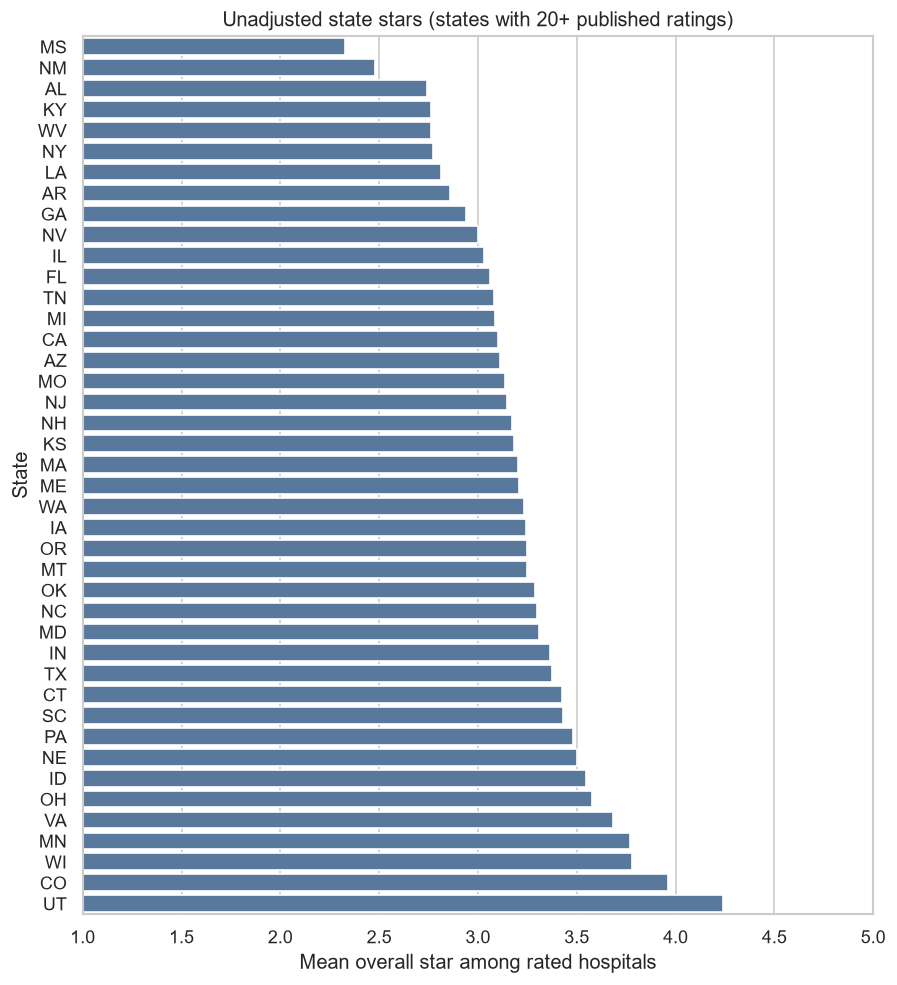

In [9]:
state = (
    mart.groupby("state", dropna=False)
    .agg(
        n_hospitals=("facility_id", "size"),
        n_star=("overall_rating", "count"),
        mean_star=("overall_rating", "mean"),
    )
    .reset_index()
)
state["pct_rated"] = state["n_star"] / state["n_hospitals"]
shown = state.loc[state["n_star"] >= 20].sort_values("mean_star")
print("states shown (n_star >= 20):", len(shown))
print("states omitted because fewer than 20 stars:")
display(
    state.loc[state["n_star"] < 20]
    .sort_values("n_star")
    [["state", "n_hospitals", "n_star", "pct_rated", "mean_star"]]
)

fig, ax = plt.subplots(figsize=(8.5, 9.5))
sns.barplot(
    data=shown,
    x="mean_star",
    y="state",
    color="#4C78A8",
    ax=ax,
)
ax.set_xlabel("Mean overall star among rated hospitals")
ax.set_ylabel("State")
ax.set_xlim(1, 5)
ax.set_title("Unadjusted state stars (states with 20+ published ratings)")
fig.savefig(FIGURES_DIR / "cms_star_by_state.png")
plt.show()


## Findings from this pass

Working notes for the briefing. Association only. No UCI.

- **Publication first.** 3,174 of 5,419 hospitals have a star. 3,253 have an HF readmission score. The South has the most hospitals and also a large unpublished share. Territory hospitals almost never have a star. Any average that ignores that count is wrong.
- **Peer spreads.** 28 peer groups have 20 or more published HF scores (2,968 of 3,253 scored hospitals). The widest large-peer spread is Midwest voluntary non-profit private acute-care (17.7 to 28.4). That 28.4 is Bronson Methodist, last of 357, and CMS-worse. The Northeast peer of the same type/ownership goes to 27.6 (St. Barnabas). Southern proprietary acute-care is large (291) but tighter (spread 6.7).
- **Review list.** CMS-worse **and** peer n ≥ 20 is the list I would hand a quality leader: **29 hospitals**. Tiny peers stay off it even if CMS printed "worse."
- **Experience.** 2,960 hospitals have both an HF score and an HCAHPS overall linear score. Pearson r is **-0.17**, Spearman **-0.15**. Direction is the expected one (better experience, slightly lower HF score) and the relationship is weak. Overall star vs HF is a bit stronger (-0.28, n=3,045) and still not a lever by itself. This is not evidence that raising HCAHPS would cut readmission.
- **States.** Among states with 20+ published stars, Utah and Colorado sit high. Several states with many hospitals publish stars on well under half of them. The chart caption has to say unadjusted.

Figures: `figures/cms_publication_by_region.png`, `figures/cms_hf_score_by_large_peer.png`, `figures/cms_hf_vs_hcahps.png`, `figures/cms_star_by_state.png`.

Next: notebook `06`, UCI segments and prior use.


In [10]:
print("saved")
for path in sorted(FIGURES_DIR.glob("cms_*.png")):
    print(path.name, path.stat().st_size)


saved
cms_hf_score_by_large_peer.png 80749
cms_hf_vs_hcahps.png 139315
cms_publication_by_region.png 43986
cms_star_by_state.png 67652
